# DoubleML IRM - Impact of scholarship on dropout probability

This notebook aims at studying the impact of granting scholarships to students in higher education in Portugal on the probability of dropping out. 
- We will be studying only students who either completed their higher education or dropped out. 
- Our treatment variable is the dummy "scholarship" which indicates scholarship holders. Our outcome variable is a dummy variable as well, which is dropping out. 
- We use *Group Average Treatment Effects (GATE)* to investigate how these effects manifest across different segments of the risk of dropping out distribution. 

**Motivation**

It makes sense to assume that the effect of receiving a scholarship has *heterogeneous effects* on dropout, and at first-order, that the marginal effect of financial aid varies according to a student’s baseline propensity to drop out (assuming there is rank preservation).  

From a policy perspective, it is interesting to study if scholarships prevent the most at risk to pursue their studies. This gives a clearer picture of the extent of the realization of the initial goals of the scolarships: they are aimed at correcting social inequalities at the beginning of higher education; lower SES students tend to struggle with financial constraints which have a cognitive cost as well as a real cost on the time allocated to studies. Less importantly, scholarships prevent students from low SES backgrounds from being excluded from the socialization that occurs during their college years (that can take forms which have a concrete financial entry cost). These factors reduce the time allocated to human capital accumulation and significantly increase the risk of academic failure.

Furthermore, in a state of national budget contraction, identifying the distribution of these effects allows for more efficient resource allocation. If scholarships act as a necessary "safety net" that allows high-risk students to substitute labor hours for study time, then targeting these individuals maximizes the social return on public investment in education.

**Challenge for DoubleML with heterogeneous effects**

This task present two statistical challenges. 

- Class imbalance: our data doesn't have much dropouts. In order to make accurate predictions, usually in Machine Learning this imbalance is taken into account by reweighting the observations. However, this will probably result in some bias and violation of Neyman orthogonality, because reweighting is an issue of the same nature as the issue solved for when dealing with the regularization bias. Another non invasive procedure that we can do is to integrate the class imbalance issue when cross-fitting our data. Thus we apply the `StratifiedKFold` to reproduce the distribution of our classes in each fold. 

- High dimensionality of confounders X: This is one of the advantages of a DoubleML procedure actually: through feature selection techniques (regularization), or through decreasing complexity of models in general (pruning for tree-based models for ex) we are able to acheive better results than classical econometrics linear models. 

Note that initially, we wished to run a *quantile regression* with a non-linear binary (here logistic) model (we assumed that rank preservation was credible in this setup), however recent econometric work on binary quantile regression is not yet implemented in the package `DoubleML` (see Horowitz (1992) for kernel smoothing of the binary model, or Florios and Skouras (2008) who use mixed integer programming in order to compute estimates). 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import warnings
from sklearn.base import clone
import multiprocessing
from sklearn.model_selection import StratifiedKFold

import doubleml as dml
warnings.filterwarnings('ignore')
from skrub import TableReport
from skrub import set_config
set_config(max_plot_columns=50)

# ── Style global ──────────────────────────────────────────────────
PALETTE_TARGET = {'Dropout': '#E63946', 'Graduate': '#2A9D8F', 'Enrolled': '#F4A261'}
PALETTE_BINARY = ['#E63946', '#2A9D8F']

sns.set_theme(style='whitegrid', palette='muted', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})


c:\Users\zargo\Programs\miniforge3\envs\ml_econ\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Fetching and preprocessing data

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
data_raw = predict_students_dropout_and_academic_success.data.features 
y_raw = predict_students_dropout_and_academic_success.data.targets 


In [3]:
# We will only keep the students that either dropped out or graduated, and drop the ones that are still enrolled.
# This way we can predict the probability of dropout on students that have already finished higher education. 
# We also encode the target variable as a binary variable, 1 being our state of interest = Dropout. 

mask = y_raw['Target'].isin(['Graduate', 'Dropout'])


data = data_raw[mask].copy()
y = y_raw[mask].copy()
y = y.replace({'Graduate': 0, 'Dropout': 1}).astype(int)



In [4]:
# One hot encoding of categorical variables and scaling of numerical variables (for DML with regularization, which is sensitive to feature scaling).

cat_features = ["Mother's occupation", "Father's occupation", "Mother's qualification", "Father's qualification", 
                "Course", "Previous qualification", 
                "Nacionality", "Marital Status", "Application order", "Application mode"
                ]

num_features = ["Admission grade","Age at enrollment", "Curricular units 1st sem (credited)", 
                "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)", 
                "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)", 
                "Curricular units 2nd sem (credited)", "Previous qualification (grade)",
                  "Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (evaluations)", 
                  "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)", 
                  "Unemployment rate", "Inflation rate", "GDP"]

other_features = data.columns.difference(cat_features + num_features).tolist()

preprocessor_dml = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('stringify', FunctionTransformer(lambda x: x.astype(str), feature_names_out='one-to-one')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')) 
        # With regularization we can keep all categories, 
        # for other models that are not regularized (like decision trees and random forests):
        # actually the performance of these tree-based models is not affected by multicollinearity, 
        # but the interpretation of feature importance can be. In our causal context, we don't need to analyze feature importance.
        # we still drop the first category to be safe when adding more models.  
    ]), cat_features),
    ('num', Pipeline([
        ('scaler', StandardScaler())
    ]), num_features),
    ('passthrough', 'passthrough', other_features)
])

data_preprocessed = preprocessor_dml.fit_transform(data)

preprocessed_feature_names = (
    preprocessor_dml
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_features)
)
all_feature_names = list(preprocessed_feature_names) + num_features + other_features


data_preprocessed_df = pd.DataFrame(data_preprocessed, columns=all_feature_names)



In [5]:
# Basic table report
TableReport(data)

Processing column  36 / 36


,,,,,,,,,,,,,,,,,,,,,,,,,


# 2. Checking Common Support Assumption

We would like to suggest evidence that $P(Scholarship = 1 | X)$ is strictly bounded between 0 and 1; this way, we allow for some variability in our data and we are able to detect a causal effect of holding a scholarship on the probability of dropping out of studies. No need for now to remove students who are still enrolled. 

In particular, we have chosen to focus on a subset of students whose propensity score for getting a scholarship (based on the covariates we have identified in the DAG - see corresponding notebook) lies between **0.05 and 0.95**. 

In [ ]:
# Confounders: variables with edges INTO both Scholarship holder AND Target
confounders_sociodemographic = [
    'Marital Status',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Nacionality',
    'Gender',
    'Age at enrollment',
    'Displaced',
    'Educational special needs',
    'International'
]

confounders_macroeconomic = [
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

# # Academic factors: only point into Target, not into Scholarship
# # Including them reduces variance of g_0(X) without introducing bias
academic_controls = [
    'Admission grade',
    'Previous qualification',
    'Previous qualification (grade)',
    'Course',
    'Daytime/evening attendance',
    'Application mode',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (without evaluations)'
]



We will not introduce academic controls because 1. post treatment variable 2. causal chain between scholarship and dropout. 
Keeping them would have given a different interpretation of the treatment effect, 
more like "the effect of scholarship on dropout, holding academic performance constant",
 which is not what we are interested in.



Another important point is that since we do not have sufficient information in the data to know WHEN 
the student dropped out (it could be at the end of semester 1 or 2, or after these), we do not study
the effect of the treatment (scholarship) on this intermediary outcome (which would have been interesting to look at). 


In [ ]:


features_full = confounders_sociodemographic + confounders_macroeconomic

#Since the preprocessing the columns are dummified so the names have changed, for clarity of the notebook we still present them this way. 
def get_preprocessed_cols(feature_list, preprocessed_cols):
    return [
        col for col in preprocessed_cols
        if any(col == feat or col.startswith(feat + "_") for feat in feature_list)
    ]


features_full_pp = get_preprocessed_cols(
    features_full,
    data_preprocessed_df.columns
)

academic_controls_pp = get_preprocessed_cols(
    academic_controls,
    data_preprocessed_df.columns
)

In [7]:


# Fit propensity score model
X = data_preprocessed_df[features_full_pp]
D = data_preprocessed_df['Scholarship holder']


In [8]:
# Dropout rate in the sample
dropout_rate = y['Target'].mean()
print(f"Dropout rate: {dropout_rate:.2%}")

Dropout rate: 39.15%


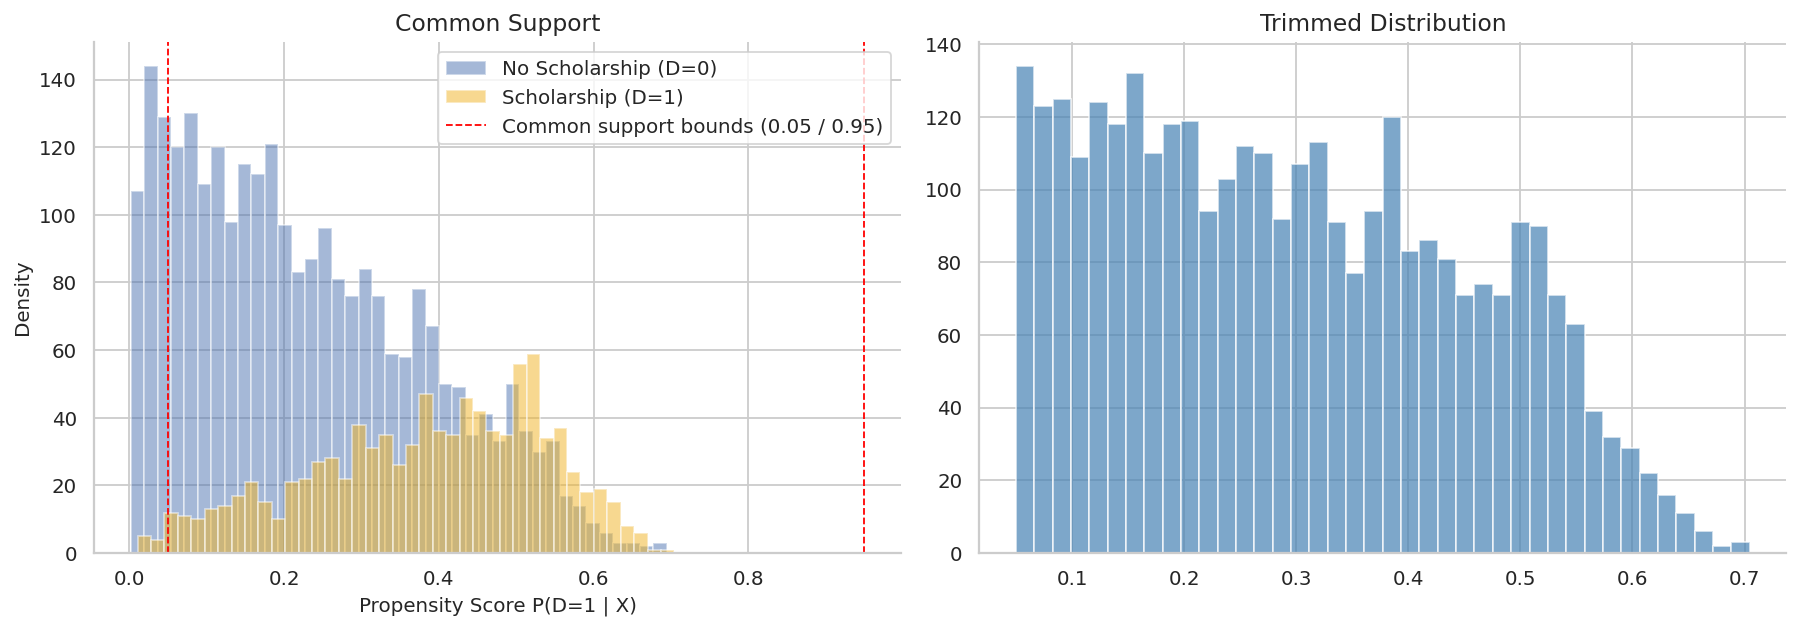

<Figure size 832x624 with 0 Axes>

Observations outside [0.05, 0.95] support: 10.0%
  Treated   outside support: 1.3%
  Untreated outside support: 13.2%


In [9]:

ps_model = LogisticRegressionCV(penalty='l1', solver='liblinear', cv=5, random_state=42)
ps_model.fit(X, D)
propensity_scores = ps_model.predict_proba(X)[:, 1]

# Split by treatment group
ps_treated   = propensity_scores[D == 1]
ps_untreated = propensity_scores[D == 0]

# Create the figure and an array of 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histograms
axes[0].hist(ps_untreated, bins=40, alpha=0.5, color='#4C72B0', label='No Scholarship (D=0)')
axes[0].hist(ps_treated,   bins=40, alpha=0.5, color='#F0B323', label='Scholarship (D=1)')
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=1, label='Common support bounds (0.05 / 0.95)')
axes[0].axvline(0.95, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Propensity Score P(D=1 | X)')
axes[0].set_ylabel('Density')
axes[0].set_title('Common Support')
axes[0].legend()

# Only for common support (propensity scores between 0.05 and 0.95)
in_support = (propensity_scores > 0.05) & (propensity_scores < 0.95)
axes[1].hist(propensity_scores[in_support], bins=40, color='steelblue', alpha=0.7)
axes[1].set_title('Trimmed Distribution')

plt.tight_layout()
plt.show()

# --- Plot 2: Trimmed overlap region ---

plt.tight_layout()
plt.show()

# Summary stats
pct_outside = (~in_support).mean() * 100
print(f"Observations outside [0.05, 0.95] support: {pct_outside:.1f}%")
print(f"  Treated   outside support: {(~in_support[D==1]).mean()*100:.1f}%")
print(f"  Untreated outside support: {(~in_support[D==0]).mean()*100:.1f}%")

In [11]:
# Characteristics of observations outside common support: do they systematically differ from those inside support?

balance_table = X.copy().assign(In_Support=in_support).groupby('In_Support')[features_full_pp].mean().T
balance_table.columns = ['Outside Support', 'Inside Support']
balance_table['Absolute Difference'] = (balance_table['Inside Support'] - balance_table['Outside Support']).abs()
print("--- Balance Table: Inside vs. Outside Common Support ---")
balance_table.sort_values('Absolute Difference', ascending=False).head(20)

--- Balance Table: Inside vs. Outside Common Support ---


,Outside Support,Inside Support,Absolute Difference
Age at enrollment,1.660633,-0.185080,1.845713
Gender,0.730769,0.300980,0.429789
Displaced,0.307692,0.575934,0.268242
Marital Status_2,0.324176,0.063993,0.260183
GDP,-0.219606,0.024475,0.244081
Mother's qualification_3,0.266484,0.073484,0.192999
Mother's qualification_19,0.060440,0.231170,0.170730
Mother's occupation_2,0.214286,0.049602,0.164684
Unemployment rate,-0.144249,0.016077,0.160326
Inflation rate,0.142050,-0.015832,0.157881


In [ ]:
# Characteristics of observations outside common support FOR ACADEMIC RESULTS: 
# do they systematically differ from those inside support?
# Note that these are post-treatment variables, this table is purely descriptive, 
# but it helps get a sense of the academic profiles of students outside common support. 

balance_table = (data_preprocessed_df[academic_controls_pp].copy().
                 assign(In_Support=in_support)
                 .groupby('In_Support')[academic_controls_pp].mean().T)
balance_table.columns = ['Outside Support', 'Inside Support']
balance_table['Absolute Difference'] = (balance_table['Inside Support'] - balance_table['Outside Support']).abs()
print("--- Balance Table: Inside vs. Outside Common Support ---")
balance_table.sort_values('Absolute Difference', ascending=False).head(20)

--- Balance Table: Inside vs. Outside Common Support ---


,Outside Support,Inside Support,Absolute Difference
Curricular units 2nd sem (grade),-0.407179,0.045381,0.452559
Curricular units 2nd sem (approved),-0.383787,0.042774,0.426561
Curricular units 1st sem (grade),-0.371646,0.041420,0.413066
Application mode_39,0.530220,0.144213,0.386007
Curricular units 1st sem (approved),-0.261446,0.029139,0.290585
Daytime/evening attendance,0.697802,0.908757,0.210955
Application mode_17,0.043956,0.213411,0.169455
Previous qualification (grade),-0.145244,0.016188,0.161432
Curricular units 2nd sem (without evaluations),0.280220,0.126761,0.153459
Course_9991,0.173077,0.046234,0.126843


In [14]:
# Keep only observations in common support for the rest of the analysis
if data_preprocessed_df.shape[0] != in_support.sum():
    print(f"Keeping only {in_support.sum()} observations in common support for the rest of the analysis (dropping {data_preprocessed_df.shape[0] - in_support.sum()} observations outside support).")
    data_preprocessed_df = data_preprocessed_df[in_support].reset_index(drop=True)
    data_preprocessed = data_preprocessed[in_support]
    y = y[in_support].reset_index(drop=True)
else:
    print("All observations are within common support, keeping all for the rest of the analysis.")

Keeping only 3266 observations in common support for the rest of the analysis (dropping 364 observations outside support).


In [15]:
# Dropout rate in the sample
dropout_rate = y['Target'].mean()
print(f"Dropout rate: {dropout_rate:.2%}")

Dropout rate: 36.25%


# 3. Double ML GATE

This first approach to heterogeneity is along one specific dimension that seemed crucial policy-wise: the baseline dropout probability in the absence of a scholarship. This approach resembles the one from Chernozhukov et al. (2023) on heterogeneous effects in randomized experiments yet here we don't perform a group ATE based on estimated score but only on estimated control mean. 

Here DDML (Chernozhukov et al., 2018) is used on top of the sample splitting approach to use flexible models on high-dimensional data (as mentioned in the introduction). 

We use sample splitting in order to first estimate the baseline risk based on socioeconomic and macro factors on an auxiliary sample, then we estimate DoubleMLIRM on a main sample (50% of whole dataset) to compute ATE, GATE across quintiles of baseline risks predicted on main sample observations from the fitting on the auxiliary sample, and confidence intervals associated with these estimates. Then we change this split for a given number of iterations. We get a collection of ATE and GATE estimates, and we take the median. Note that our confidence interval thus went from a confidence level of 95% to a confidence level of 90%. 

From Yadlowsky et al. (2025): 

>A popular alternative [to CATE] is to first estimate the baseline probability of the outcome in absence of any intervention, and then use this as a non-causal heuristic to prioritize individuals with a high baseline risk (Kent et al., 2016, 2020). There is considerable interest in understanding the extent to which risk-based rules are sufficient for making high-quality individualized intervention decisions. For example, in medical settings, this may work well for preventative treatments where the treatment reduces the risk of an event occurring, as patients with a higher baseline risk have the most potential for benefit. In such cases, the heterogeneous treatment effect is correlated with baseline risk, but the amount of data available to build such a risk score may be much larger than that available for treatment effect estimation (Kent et al., 2020), so a risk based approach may work better.



Note that the reported bands reflect empirical variability across splits, not a frequentist confidence guarantee at a known level. This is one of the limitations of our approach. 

In [16]:
# DoubleMLData backend 
data_dml = dml.DoubleMLData(
    data_preprocessed_df.assign(
        Target=y['Target'].values),
    y_col='Target',
    d_cols='Scholarship holder',
    x_cols=features_full_pp,
)


In [ ]:
# Distribution of target variable by treatment group
pd.crosstab(data_preprocessed_df['Scholarship holder'], y['Target'])

Target,0,1
Scholarship holder,,
0.0,1254,1056
1.0,828,128


In [17]:
learners = {
    'Logistic L1': LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        random_state=42 #shuffling the data (not for cross-validation)
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=5,           
        min_samples_leaf=20,   
        n_jobs=-1,
        random_state=42
    ),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(100, 50, 25),
        learning_rate_init=0.001,
        alpha=0.01, # L2 regularization
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ), 
    'Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=3, 
        random_state=42)
}

In [ ]:
#DoubleML-IRM + GATES heterogeneity

n_iterations = 100 # number of iterations for sample splitting
results = {}


# Sample Split à la Chernozukhov: Main (M) and Auxiliary (A), in order to 
# compute the baseline risk g₀(X) on the auxiliary sample 
# and then compute GATES on the main sample using the auxiliary sample's predictions


for learner_name, learner in learners.items():
    all_gate_coefs = []
    all_gate_upper_cis = []
    all_gate_lower_cis = []
    all_ate_coefs = []
    all_ate_upper_cis = []
    all_ate_lower_cis = []


    print(f"\n{'='*60}",
          f"\nFitting DoubleIRM with split sampling... — {learner_name}\n",
          f"{'='*60}")
    
    for i in range(n_iterations):

    # Because of class imbalances, we use stratified splitting to ensure that
    # each fold has a representative proportion of treated and control observations

        print(f"\n{'='*60}",
          f"\nIteration {i+1}...\n",
          f"{'='*60}")
        
        stratify_cols = pd.Series(data_dml.y).astype(str) + "_" + pd.Series(data_dml.d.flatten()).astype(str)
        idx_m, idx_a = train_test_split(
            np.arange(data_dml.n_obs), 
            test_size=0.5, 
            random_state=i, # Changing seed each iteration
            stratify=stratify_cols
        )
        # Subset data for the two samples
        data_dml_m = dml.DoubleMLData.from_arrays(
            x = data_dml.x[idx_m, :],
            y = data_dml.y[idx_m],
            d = data_dml.d[idx_m]
        )
        
        data_dml_a = dml.DoubleMLData.from_arrays(
            x = data_dml.x[idx_a, :],
            y = data_dml.y[idx_a],
            d = data_dml.d[idx_a]
        )

        learner_g0 = clone(learner)
        X_a_ctrl = data_dml_a.x[data_dml_a.d.flatten() == 0]
        y_a_ctrl = data_dml_a.y[data_dml_a.d.flatten() == 0]
        learner_g0.fit(X_a_ctrl, y_a_ctrl)
        
        print(f"\n{'='*60}")
        print(f"Fitting DoubleML IRM — {learner_name}")
        print(f"{'='*60}")

        dml_irm = dml.DoubleMLIRM(
            data_dml_m,
            ml_g=clone(learner),
            ml_m=clone(learner),
            score='ATE',
            normalize_ipw=True,
            trimming_threshold=0, # don't drop more observations since we already dropped some in the previous section
            draw_sample_splitting=False,
        )

        # Stratification again for class imbalance reasons

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        smpls = [(train, test) for train, test in skf.split(data_dml_m.x, data_dml_m.y)]

        # Fit on sample M
        dml_irm.set_sample_splitting(smpls).fit()


        # ATE Estimation and confidence interval
        ate = float(dml_irm.coef[0])
        ci  = dml_irm.confint(level=0.95)

        all_ate_coefs.append(ate)
        all_ate_lower_cis.append(ci.iloc[0, 0])
        all_ate_upper_cis.append(ci.iloc[0, 1])

        print(f"  ATE = {ate:.4f}   95% CI [{ci.iloc[0,0]:.4f}, {ci.iloc[0,1]:.4f}]")

        # ĝ₀(X) = out-of-sample prediction of E[Y | D=0, X]
        g0_hat_m = learner_g0.predict_proba(data_dml_m.x)[:, 1]

        # GATES: 5 groups by risk quintile
        n_groups    = 5
        risk_labels = pd.qcut(g0_hat_m, q=n_groups, labels=[1, 2, 3, 4, 5])
        groups_df = pd.DataFrame(risk_labels)

        gate      = dml_irm.gate(groups=groups_df)
        gate_ci   = gate.confint(level=0.95, joint=False)   # pointwise
        current_coefs = gate_ci['effect'].values
        current_lower = gate_ci['2.5 %'].values
        current_upper = gate_ci['97.5 %'].values

        # Add upper and lower bounds of the pointwise confidence intervals
        # to the list (going to get the median of the upper and lower bounds
        #  across iterations for each group)
        all_gate_coefs.append(current_coefs)
        all_gate_lower_cis.append(current_lower)
        all_gate_upper_cis.append(current_upper)


    #Get the median for each group across iterations of {γ_hat_k,A} and {l(0.05)A, u(0.05)A}. 
    median_ate_coefs = np.nanmedian(np.array(all_ate_coefs), axis=0)
    median_ate_lower = np.nanmedian(np.array(all_ate_lower_cis), axis=0)
    median_ate_upper = np.nanmedian(np.array(all_ate_upper_cis), axis=0)

    median_gate_coefs = np.nanmedian(np.array(all_gate_coefs), axis=0)
    median_gate_lower = np.nanmedian(np.array(all_gate_lower_cis), axis=0)
    median_gate_upper = np.nanmedian(np.array(all_gate_upper_cis), axis=0)


    results[learner_name] = {
        'irm': dml_irm,
        'ate_coef':median_ate_coefs, 
        'ate_ci_lower': median_ate_lower, 
        'ate_ci_upper': median_ate_upper,
        'risk_labels': risk_labels,
        'gate_coefs': median_gate_coefs,
        'gate_ci_lower': median_gate_lower,
        'gate_ci_upper': median_gate_upper} # replace this object with the median of the upper and lower bounds of the pointwise confidence intervals across iterations for each group, and the median of the gate coefficients across iterations for each group.




Fitting DoubleIRM with split sampling... — Logistic L1

Iteration 1...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2949   95% CI [-0.3578, -0.2321]

Iteration 2...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2587   95% CI [-0.3181, -0.1993]

Iteration 3...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2391   95% CI [-0.2970, -0.1811]

Iteration 4...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2307   95% CI [-0.2950, -0.1664]

Iteration 5...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2436   95% CI [-0.2998, -0.1875]

Iteration 6...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2761   95% CI [-0.3402, -0.2120]

Iteration 7...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.3025   95% CI [-0.3693, -0.2357]

Iteration 8...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2659   95% CI [-0.3200, -0.2117]

Iteration 9...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2799   95% CI [-0.3377, -0.2221]

Iteration 10...

Fitting DoubleML IRM — Logistic L1
  ATE = -0.2624   95% CI [-

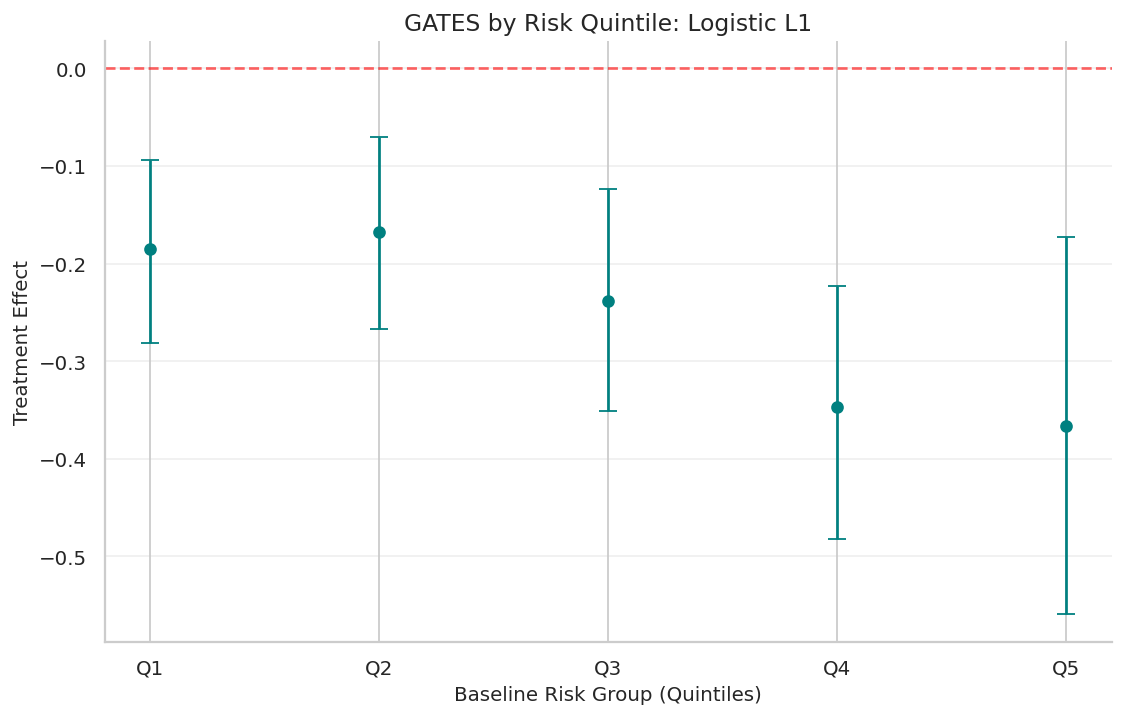

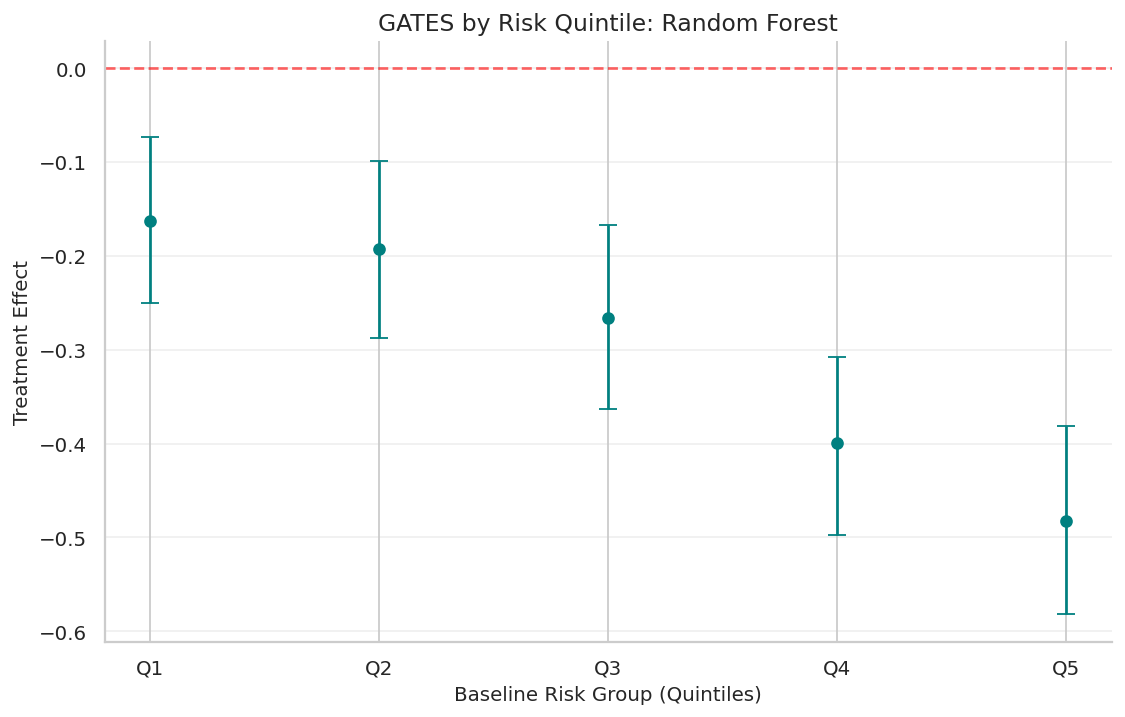

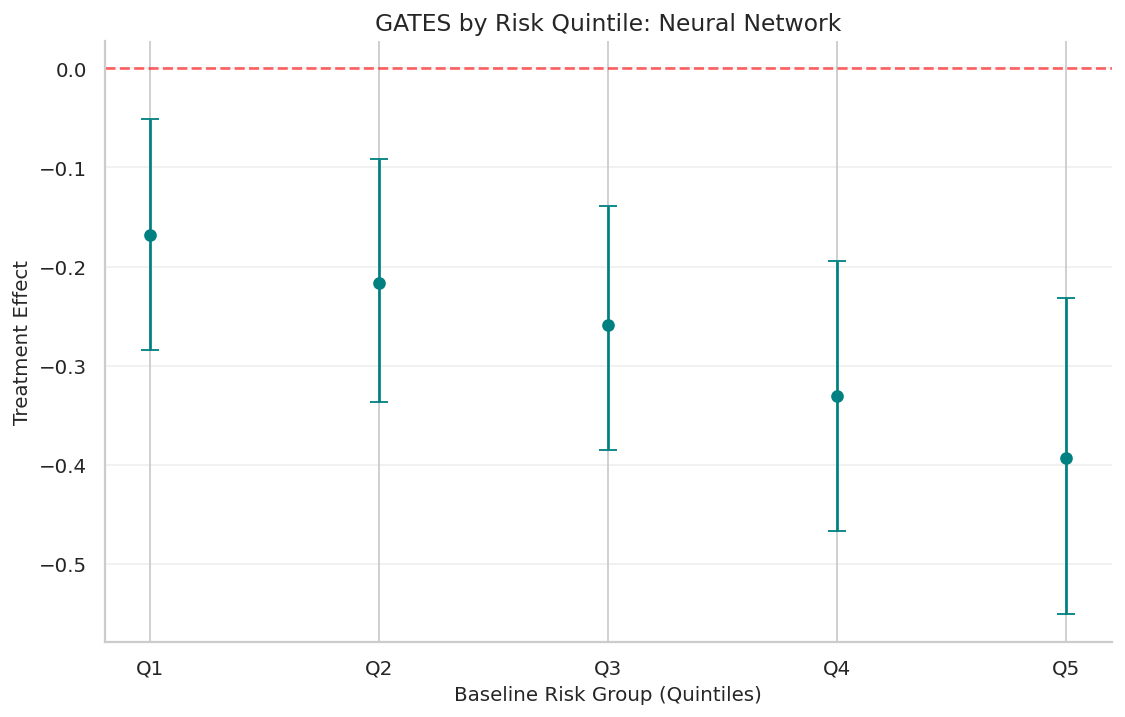

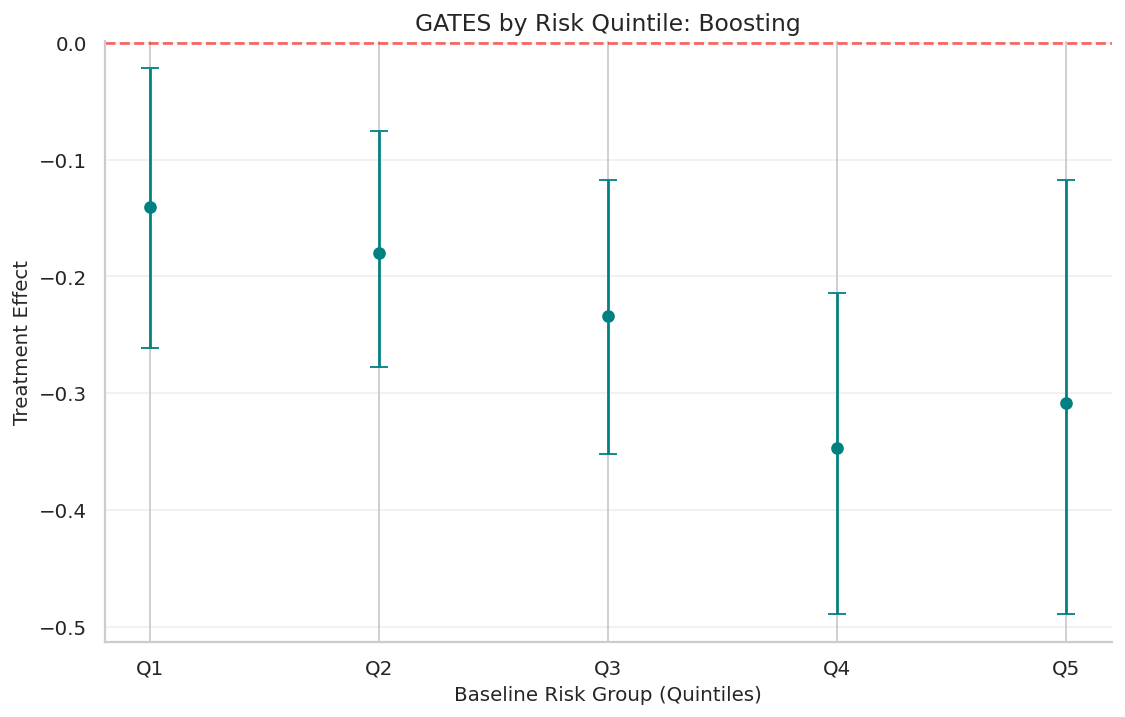

In [25]:
def get_stars(lower, upper):
    if lower > 0 or upper < 0:
        return "***"  # Simplified heuristic for CI-based significance
    return ""

summary_data = []

for learner_name, res in results.items():
    # 1. Plotting GATES
    plt.figure(figsize=(10, 6))
    groups = [f"Q{i+1}" for i in range(len(res['gate_coefs']))]
    
    # Calculate error bars for plt.errorbar (requires relative offsets)
    yerr_lower = res['gate_coefs'] - res['gate_ci_lower']
    yerr_upper = res['gate_ci_upper'] - res['gate_coefs']
    
    plt.errorbar(groups, res['gate_coefs'], yerr=[yerr_lower, yerr_upper], 
                 fmt='o', capsize=5, color='teal', label='GATE')
    
    plt.axhline(0, color='red', linestyle='--', alpha=0.6)
    plt.title(f"GATES by Risk Quintile: {learner_name}")
    plt.ylabel("Treatment Effect")
    plt.xlabel("Baseline Risk Group (Quintiles)")
    # plt.set_xticklabels([f'Q{i+1}\n{"(lowest risk)" if i==0 else "(highest risk)" if i==4 else ""} '
    #                     for i in range(len(res['gate_coefs']))], fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    plt.savefig(f"outputs/2 - GATES_{learner_name.replace(' ', '_')}.png", bbox_inches='tight')
    plt.show()

    # 2. Collect data for Tables
    # Add ATE
    summary_data.append({
        'Learner': learner_name,
        'Group': 'Full Sample (ATE)',
        'Estimate': res['ate_coef'],
        'Lower CI': res['ate_ci_lower'],
        'Upper CI': res['ate_ci_upper'],
        'Stars': get_stars(res['ate_ci_lower'], res['ate_ci_upper'])
    })
    
    # Add GATES
    for i in range(len(res['gate_coefs'])):
        summary_data.append({
            'Learner': learner_name,
            'Group': f"Quintile {i+1}",
            'Estimate': res['gate_coefs'][i],
            'Lower CI': res['gate_ci_lower'][i],
            'Upper CI': res['gate_ci_upper'][i],
            'Stars': get_stars(res['gate_ci_lower'][i], res['gate_ci_upper'][i])
        })

df_results = pd.DataFrame(summary_data)


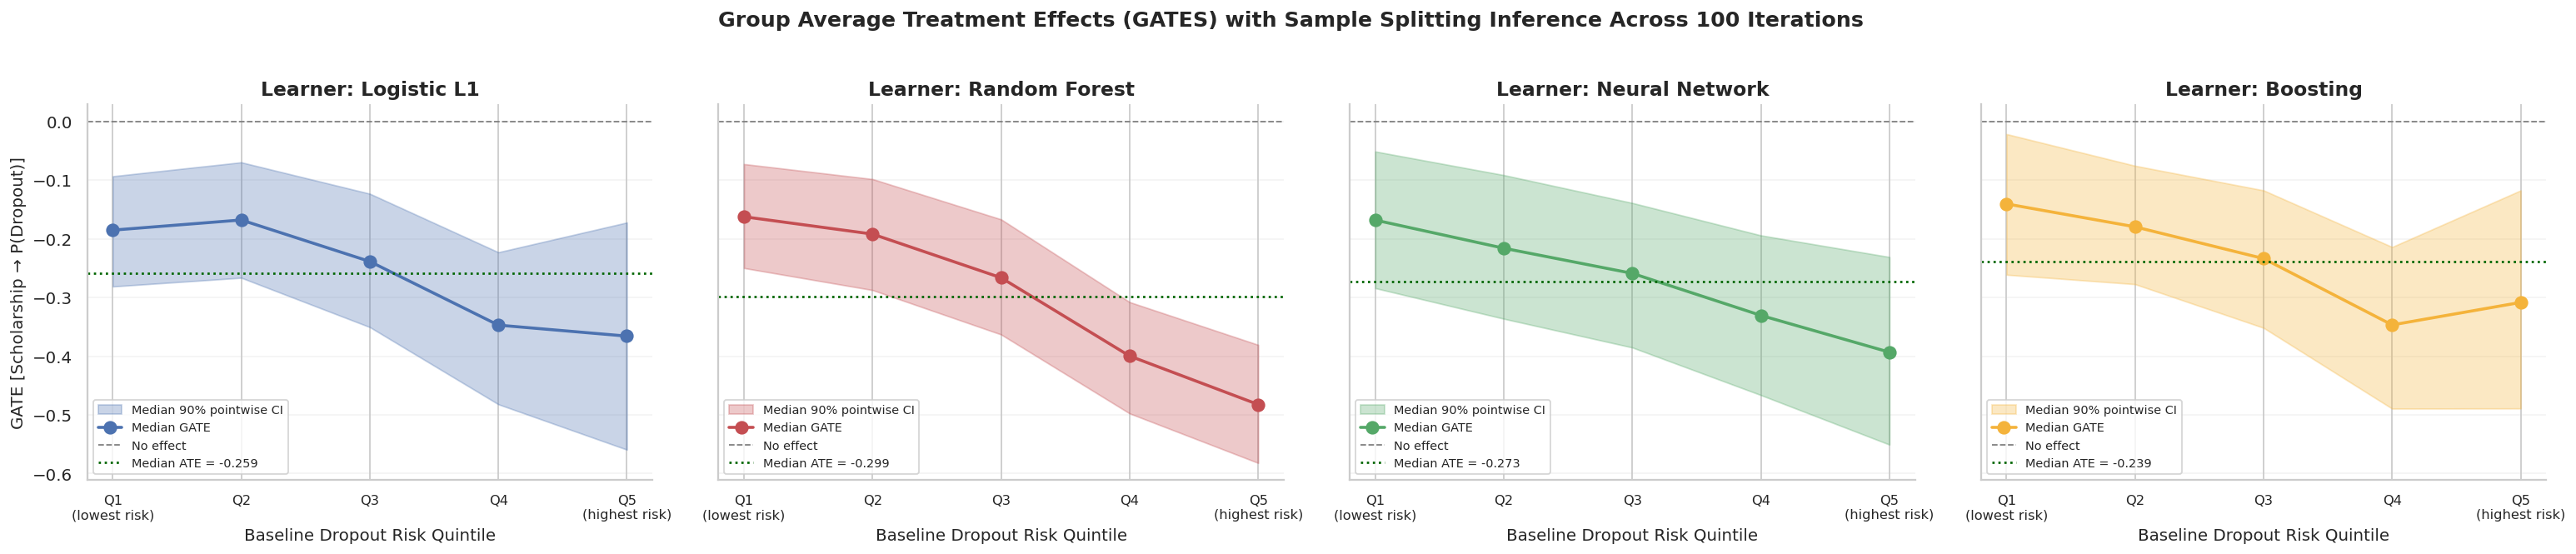

In [26]:
# Define colors to match your original style
colors = {'Logistic L1': '#4C72B0', 'Neural Network': '#55A868','Boosting': "#F4B33B", 'Random Forest': '#C44E52'}
n_groups = 5

# Create the figure
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5), sharey=True)

# Handle case where there's only one learner (axes wouldn't be a list)
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    c = colors.get(name, '#333333')
    
    # Extract median values stored in your results dict
    coef  = res['gate_coefs']
    lo_pw = res['gate_ci_lower']
    hi_pw = res['gate_ci_upper']
    ate   = res['ate_coef']
    
    x = np.arange(1, n_groups + 1)

    # 1. Shaded area for Pointwise Confidence Interval
    ax.fill_between(x, lo_pw, hi_pw, alpha=0.3, color=c, label='Median 90% pointwise CI')
    
    # 2. Plot the median coefficients
    ax.plot(x, coef, 'o-', color=c, markersize=8, linewidth=2, label='Median GATE')
    
    # 3. Reference lines
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='No effect')
    ax.axhline(ate, color='darkgreen', linestyle=':', linewidth=1.5, 
               label=f'Median ATE = {ate:.3f}')
    
    # 4. Formatting labels
    ax.set_xticks(x)
    labels = [f'Q{i}\n{"(lowest risk)" if i==1 else "(highest risk)" if i==5 else ""}' for i in x]
    ax.set_xticklabels(labels, fontsize=9)
    
    ax.set_title(f"Learner: {name}", fontweight='bold')
    ax.set_xlabel('Baseline Dropout Risk Quintile')
    if ax == axes[0]:
        ax.set_ylabel('GATE [Scholarship → P(Dropout)]')
    
    ax.legend(fontsize=8, loc='best')
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Group Average Treatment Effects (GATES) with Sample Splitting Inference Across 100 Iterations', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("outputs/2 - GATES_Sample_Splitting.png", bbox_inches='tight')


plt.show()

In [23]:

# Summary Table of ATE and GATES results
print("### Results Summary Table")
df_results



### Results Summary Table


,Learner,Group,Estimate,Lower CI,Upper CI,Stars
0,Logistic L1,Full Sample (ATE),-0.258770,-0.318168,-0.200024,***
1,Logistic L1,Quintile 1,-0.185412,-0.281348,-0.093670,***
2,Logistic L1,Quintile 2,-0.168122,-0.266566,-0.069945,***
3,Logistic L1,Quintile 3,-0.238811,-0.350614,-0.123411,***
4,Logistic L1,Quintile 4,-0.347174,-0.481993,-0.223102,***
5,Logistic L1,Quintile 5,-0.365892,-0.559253,-0.172425,***
6,Random Forest,Full Sample (ATE),-0.298882,-0.342047,-0.255775,***
7,Random Forest,Quintile 1,-0.162596,-0.250019,-0.072906,***
8,Random Forest,Quintile 2,-0.192142,-0.287491,-0.098473,***
9,Random Forest,Quintile 3,-0.266475,-0.363118,-0.167065,***


In [27]:
# Summary Table for final presentation

print("\n### LaTeX Code")
latex_code = df_results.copy()
latex_code['Estimate'] = latex_code.apply(
    lambda x: f"{x['Estimate']:.3f}^{{{x['Stars']}}}", axis=1
)
latex_code['CI'] = latex_code.apply(
    lambda x: f"({x['Lower CI']:.3f}, {x['Upper CI']:.3f})", axis=1
)
print(latex_code[['Learner', 'Group', 'Estimate', 'CI']].to_latex(index=False, escape=False))

with open("outputs/2 - Results_Summary_Table.tex", "w") as f:
    f.write(latex_code[['Learner', 'Group', 'Estimate', 'CI']].to_latex(index=False, escape=False))


### LaTeX Code
\begin{tabular}{llll}
\toprule
Learner & Group & Estimate & CI \\
\midrule
Logistic L1 & Full Sample (ATE) & -0.259^{***} & (-0.318, -0.200) \\
Logistic L1 & Quintile 1 & -0.185^{***} & (-0.281, -0.094) \\
Logistic L1 & Quintile 2 & -0.168^{***} & (-0.267, -0.070) \\
Logistic L1 & Quintile 3 & -0.239^{***} & (-0.351, -0.123) \\
Logistic L1 & Quintile 4 & -0.347^{***} & (-0.482, -0.223) \\
Logistic L1 & Quintile 5 & -0.366^{***} & (-0.559, -0.172) \\
Random Forest & Full Sample (ATE) & -0.299^{***} & (-0.342, -0.256) \\
Random Forest & Quintile 1 & -0.163^{***} & (-0.250, -0.073) \\
Random Forest & Quintile 2 & -0.192^{***} & (-0.287, -0.098) \\
Random Forest & Quintile 3 & -0.266^{***} & (-0.363, -0.167) \\
Random Forest & Quintile 4 & -0.400^{***} & (-0.498, -0.308) \\
Random Forest & Quintile 5 & -0.482^{***} & (-0.582, -0.381) \\
Neural Network & Full Sample (ATE) & -0.273^{***} & (-0.335, -0.210) \\
Neural Network & Quintile 1 & -0.168^{***} & (-0.284, -0.051) \\
Ne